# EpiLink compatibility walkthrough

This notebook shows a practical EpiLink workflow:

- create a transmission profile and an `EpiLink` scorer
- inspect detailed per-scenario compatibility for one sampled pair
- explore interactive heatmaps over sampling interval and genetic distance for AD scenarios, CA scenarios, and target subsets

It assumes `epilink` is installed in the current environment, for example with `pip install -e .` from the project root.


In [8]:
import matplotlib.pyplot as plt
import numpy as np

from epilink import (
    EpiLink,
    InfectiousnessToTransmission,
    NaturalHistoryParameters,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "figure.titlesize": 18,
    }
)

rng_seed = 2026


## Build an `EpiLink` model

We will use the infectiousness-to-transmission profile, configure a modest hidden-depth limit, and define a recent-linkage target subset consisting of direct transmission and co-primary infection.


In [9]:
parameters = NaturalHistoryParameters()
profile = InfectiousnessToTransmission(parameters=parameters, rng_seed=rng_seed)

epilink = EpiLink(
    transmission_profile=profile,
    maximum_depth=2,
    mc_samples=8000,
    target=["ad(0)", "ca(0,0)"],
    mutation_process="stochastic",
)

direct_model = epilink.pairwise_model("ad(0)")
coprimary_model = epilink.pairwise_model("ca(0,0)")
recent_linkage_model = epilink.pairwise_model(["ad(0)", "ca(0,0)"])

print("Configured target subset:", epilink.target_labels)
print("Available scenarios:", [scenario.label() for scenario in epilink.scenarios])


Configured target subset: ('ad(0)', 'ca(0,0)')
Available scenarios: ['ad(0)', 'ad(1)', 'ad(2)', 'ca(0,0)', 'ca(0,1)', 'ca(0,2)', 'ca(1,0)', 'ca(1,1)', 'ca(2,0)']


## Transmission-profile intuition

Before scoring pairs, it is useful to look at the underlying transmission-time density. This controls the temporal part of the compatibility calculation.


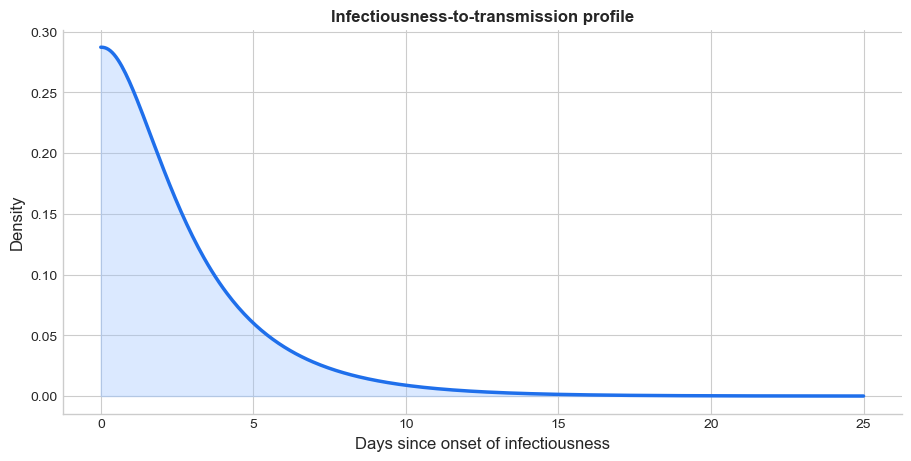

In [11]:
time_axis = np.linspace(0, 25, 400)
profile_density = profile.pdf(time_axis)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.plot(time_axis, profile_density, color="#1f6feb", linewidth=2.5)
ax.fill_between(time_axis, profile_density, color="#99c2ff", alpha=0.35)
ax.set(
    title="Infectiousness-to-transmission profile",
    xlabel="Days since onset of infectiousness",
    ylabel="Density",
)
plt.show()


## Inspect a single sampled pair

`score_pair()` is the detailed scalar interface: it returns compatibility components for every scenario as well as the score for the configured target subset.


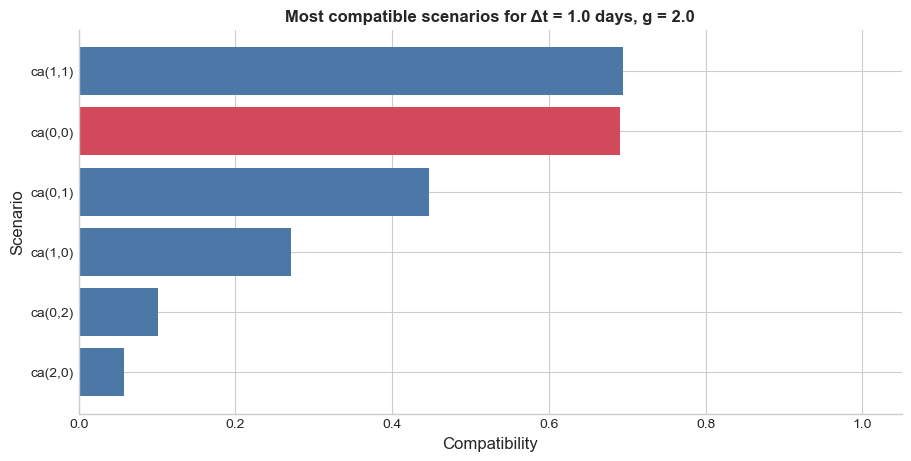

Target subset score: 0.7158883749999999


In [14]:
sample_time_difference = 1.0
genetic_distance = 2.0

pair_result = epilink.score_pair(
    sample_time_difference=sample_time_difference,
    genetic_distance=genetic_distance,
)

ranked = sorted(
    pair_result["scenario_scores"].items(),
    key=lambda item: item[1]["compatibility"],
    reverse=True,
)
top_labels = [label for label, _ in ranked[:6]]
top_scores = [values["compatibility"] for _, values in ranked[:6]]
target_labels = set(pair_result["target_labels"])

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
bar_colors = [
    "#d1495b" if label in target_labels else "#4c78a8"
    for label in top_labels[::-1]
]
ax.barh(top_labels[::-1], top_scores[::-1], color=bar_colors, edgecolor="none")
ax.set(
    title=f"Most compatible scenarios for Δt = {sample_time_difference:.1f} days, g = {genetic_distance:.1f}",
    xlabel="Compatibility",
    ylabel="Scenario",
)
ax.set_xlim(0, max(1.05, max(top_scores) * 1.05))
plt.show()

print("Target subset score:", pair_result["target_compatibility"])


## Interactive compatibility heatmap

Instead of showing many separate plots, we can use one heatmap with sample-time difference and genetic distance on the axes, then switch between ancestor-descendant scenarios, common-ancestor scenarios, and target subsets with interactive controls.

For target subsets, the score is summed across scenarios, so those heatmaps can exceed 1.


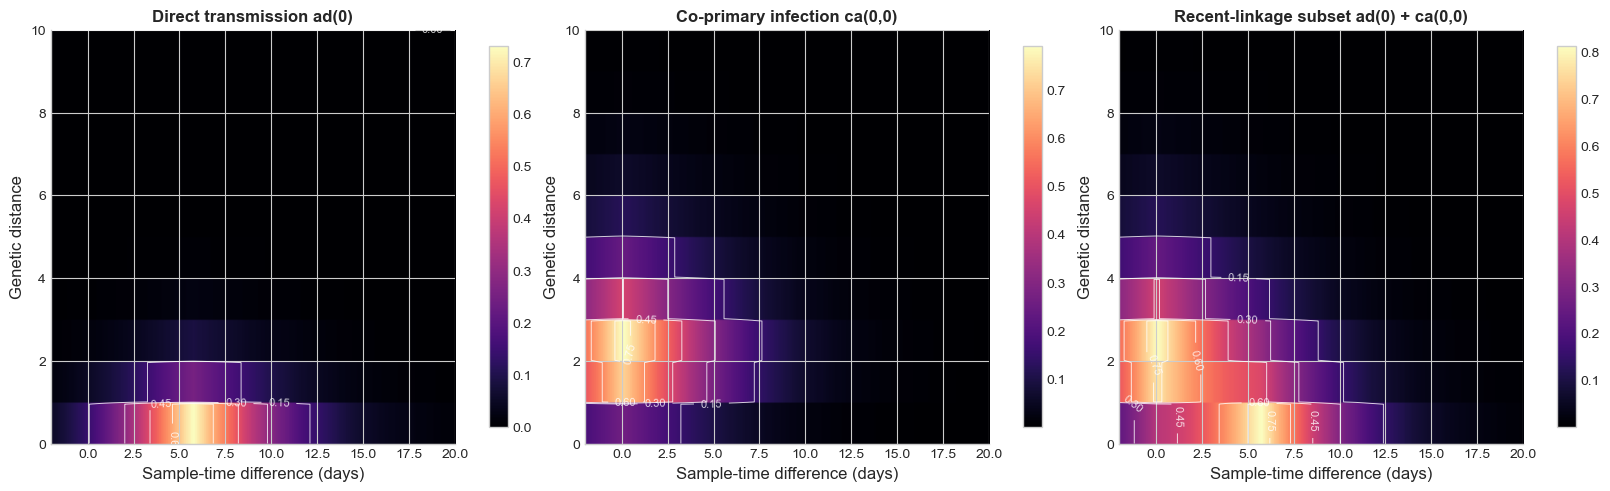

In [5]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError as exc:
    raise ImportError(
        "This cell requires ipywidgets. Install it with `pip install ipywidgets` to use the interactive heatmap controls."
    ) from exc


time_grid = np.linspace(-2, 20, 140)
genetic_grid = np.linspace(0, 10, 140)
T, G = np.meshgrid(time_grid, genetic_grid)

ad_labels = [scenario.label() for scenario in epilink.scenarios if scenario.kind == "ad"]
ca_labels = [scenario.label() for scenario in epilink.scenarios if scenario.kind == "ca"]
all_labels = [scenario.label() for scenario in epilink.scenarios]

target_models = {
    "Configured target subset": epilink.pairwise_model(),
    "All ancestor-descendant scenarios": epilink.pairwise_model(ad_labels),
    "All common-ancestor scenarios": epilink.pairwise_model(ca_labels),
    "All scenarios": epilink.pairwise_model(all_labels),
}
ad_models = {label: epilink.pairwise_model(label) for label in ad_labels}
ca_models = {label: epilink.pairwise_model(label) for label in ca_labels}

surface_cache = {}


def get_surface(cache_key, model):
    if cache_key not in surface_cache:
        surface_cache[cache_key] = model(T, G)
    return surface_cache[cache_key]


view = widgets.ToggleButtons(
    options=[
        ("Target subset", "target"),
        ("AD scenario", "ad"),
        ("CA scenario", "ca"),
    ],
    description="View:",
)

target_choice = widgets.Dropdown(
    options=list(target_models.keys()),
    value="Configured target subset",
    description="Target:",
    layout=widgets.Layout(width="460px"),
)

ad_choice = widgets.SelectionSlider(
    options=ad_labels,
    value=ad_labels[0],
    description="AD:",
    continuous_update=False,
    layout=widgets.Layout(width="460px"),
)

ca_choice = widgets.SelectionSlider(
    options=ca_labels,
    value=ca_labels[0],
    description="CA:",
    continuous_update=False,
    layout=widgets.Layout(width="460px"),
)

output = widgets.Output()


def sync_controls():
    target_choice.layout.display = "" if view.value == "target" else "none"
    ad_choice.layout.display = "" if view.value == "ad" else "none"
    ca_choice.layout.display = "" if view.value == "ca" else "none"


def draw_heatmap(*_):
    sync_controls()

    if view.value == "target":
        label = target_choice.value
        model = target_models[label]
        title = f"Compatibility heatmap: {label}"
        colorbar_label = "Compatibility (summed across scenarios)"
    elif view.value == "ad":
        label = ad_choice.value
        model = ad_models[label]
        title = f"Compatibility heatmap: {label}"
        colorbar_label = "Compatibility"
    else:
        label = ca_choice.value
        model = ca_models[label]
        title = f"Compatibility heatmap: {label}"
        colorbar_label = "Compatibility"

    surface = get_surface((view.value, label), model)

    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
        image = ax.imshow(
            surface,
            origin="lower",
            extent=[time_grid.min(), time_grid.max(), genetic_grid.min(), genetic_grid.max()],
            aspect="auto",
            cmap="magma",
        )
        contours = ax.contour(
            time_grid,
            genetic_grid,
            surface,
            levels=6,
            colors="white",
            linewidths=0.7,
            alpha=0.8,
        )
        ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
        ax.set(
            title=title,
            xlabel="Sample-time difference (days)",
            ylabel="Genetic distance",
        )
        fig.colorbar(image, ax=ax, shrink=0.92, label=colorbar_label)
        plt.show()


for control in (view, target_choice, ad_choice, ca_choice):
    control.observe(draw_heatmap, names="value")

sync_controls()
display(widgets.VBox([view, target_choice, ad_choice, ca_choice, output]))
draw_heatmap()


## Next steps

A few easy extensions from here:

- increase `maximum_depth` to expose deeper AD and CA scenarios in the interactive controls
- switch to `mutation_process="deterministic"` or `"stochastic"` to compare smoother and noisier heatmaps
- change the configured target subset to match your study definition of plausible linkage
- use the same `pairwise_model()` pattern to build cohort-level summaries or custom visualisations
